### Simple LinearRegression

In [268]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

In [269]:
class OLinearRegression:
    def __init__(self,x,y):
        self.x=x
        self.y=y
    
    def fit(self,type='ols'):
        if type=='ols':
            num=0
            den=0
            for i in range(1,len(self.x)):
                meanx=np.average(self.x)
                meany=np.average(self.y)
                num+=(self.y[i]-meany)*(self.x[i]-meanx)
                den+=(self.x[i]-meanx)**2
            if den==0:
                raise RuntimeError
            else: 
                b1=num/den
                b0=meany-b1*meanx
                self.b0=b0
                self.b1=b1
            result= "Model fitting was successful"
        elif type=='grad descent':
            alp=0.05
            theta0=0
            theta1=1
            for _ in range(1,2):
                for i in range(0,len(self.x)):
                    cost=(1/len(self.x))*(theta0+theta1*self.x[i]-self.y[i])
                    theta0=theta0-((alp/len(self.x))*(sum(theta0+theta1*self.x-self.y)))
                    theta1=theta1-((alp/len(self.x))*(sum((theta0+theta1*self.x-self.y)*self.x)))
                    self.theta1=theta1
                    self.theta0=theta0
            result=theta0+theta1*self.x
        return result                
    
    def predict(self,input_x):
        result=self.b0+self.b1*input_x
        return result

In [ ]:
class OLinearRegression:
    def __init__(self,X,y):
        if len(X.shape)!=2:
            self.X=X.reshape(1,X.shape[0])
        else:
            self.X=X
        self.y=y
    
    def std_inner_prod(self,a,b):
        '''
        a is X and b is theta
        '''
        return np.matmul(b,a.T)

    def fit(self,alp=0.01,epochs=10):
        self.X=np.array(self.X)
        self.y=np.array(self.y).reshape(1,self.y.shape[0])
        X0=np.ones(shape=(self.X.shape[0],1))
        self.X=np.concat([X0,self.X],axis=1)
        theta=np.ones(shape=(1,self.X.shape[1]))
        for epoch in range(0,epochs,1):    
            theta1=theta.copy() ## similar to gauss jocobi method not guass ciedel or Coordinate ascent
            for j in range(0,self.X.shape[1],1):
                c=np.sum(((self.std_inner_prod(self.X,theta1)-self.y))*(self.X[:,j].reshape((1,self.X.shape[0]))))
                theta[0][j]=theta1[0][j]-((alp/self.X.shape[0])*c)
        self.theta=theta
        return 'Model was fitted successfully'

    def predict(self,X_for_pred):
        X0=np.ones(shape=(X_for_pred.shape[0],1))
        X_for_pred=np.concat([X0,X_for_pred],axis=1)
        return self.std_inner_prod(X_for_pred,self.theta).reshape(X_for_pred.shape[0])

In [ ]:
lf,alp=0.01,epochs=10):
        self.X=np.array(self.X)
        self.y=np.array(self.y).reshape(1,self.y.shape[0])
        X0=np.ones(shape=(self.X.shape[0],1))
        self.X=np.concat([X0,self.X],axis=1)
        theta=np.ones(shape=(1,self.X.shape[1]))
        for epoch in range(0,epochs,1):    
            theta1=theta.copy() ## similar to gauss jocobi method not guass ciedel or Coordinate ascent
            for j in range(0,self.X.shape[1],1):
                c=np.sum(((self.std_inner_prod(self.X,theta1)-self.y))*(self.X[:,j].reshape((1,self.X.shape[0]))))
                theta[0][j]=theta1[0][j]-((alp/self.X.shape[0])*c)
        self.theta=theta
        return 'Model was fitted successfully'

    def predict(self,X_for_pred):
        X0=np.ones(shape=(X_for_pred.shape[0],1))
        X_for_pred=np.concat([X0,X_for_pred],axis=1)
        return self.std_inner_prod(X_for_pred,self.theta).reshape(X_for_pred.shape[0])

In [302]:
import numpy as np

np.random.seed(42)
m = 100 # Number of samples

# Features: 100 rows, 2 columns
X = np.random.rand(m, 2) * 10 

# Parameters: Intercept=10, Theta1=3, Theta2=5
true_theta = np.array([3, 5])
intercept = 10

# Target: Matrix multiplication + intercept + noise
y = (X @ true_theta) + intercept + (np.random.randn(m) * 2)


In [304]:
linreg=OLinearRegression(X,y)
linreg.fit(epochs=100)
y_pred=linreg.predict(X)
mean_squared_error(y_pred,y)

10.843248488415739

In [307]:
X

array([[3.74540119, 9.50714306],
       [7.31993942, 5.98658484],
       [1.5601864 , 1.5599452 ],
       [0.58083612, 8.66176146],
       [6.01115012, 7.08072578],
       [0.20584494, 9.69909852],
       [8.32442641, 2.12339111],
       [1.81824967, 1.8340451 ],
       [3.04242243, 5.24756432],
       [4.31945019, 2.9122914 ],
       [6.11852895, 1.39493861],
       [2.92144649, 3.66361843],
       [4.56069984, 7.85175961],
       [1.99673782, 5.14234438],
       [5.92414569, 0.46450413],
       [6.07544852, 1.70524124],
       [0.65051593, 9.48885537],
       [9.65632033, 8.08397348],
       [3.04613769, 0.97672114],
       [6.84233027, 4.40152494],
       [1.22038235, 4.9517691 ],
       [0.34388521, 9.09320402],
       [2.58779982, 6.62522284],
       [3.11711076, 5.20068021],
       [5.46710279, 1.84854456],
       [9.69584628, 7.75132823],
       [9.39498942, 8.9482735 ],
       [5.97899979, 9.21874235],
       [0.88492502, 1.95982862],
       [0.45227289, 3.25330331],
       [3.

In [313]:
import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(go.Scatter3d(
    x=xx.ravel(),
    y=yy.ravel(),
    z=y_pred_grid.ravel(),
    mode="markers",
    name="Prediction grid",
    marker=dict(size=2, color="blue", opacity=0.4)
))

fig.add_trace(go.Scatter3d(
    x=X[:, 0],
    y=X[:, 1],
    z=y,
    mode="markers",
    name="Actual data",
    marker=dict(size=5, color="red", opacity=0.9)
))

fig.show()


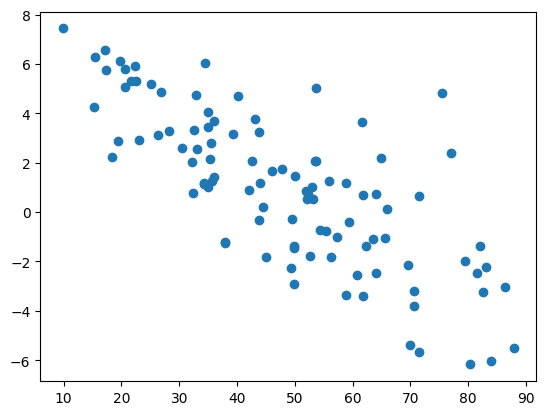

In [306]:
residue=y-y_pred
plt.scatter(y_pred,residue)